# Laboratorio 1 - Exploración, preparación y regresión lineal

## Caso AlpesPlanck

### Integrantes

Santiago Tenjo 202113965

Ali Cifci 202210698

---

El Instituto AlpesPlanck registra variables meteorológicas cada 10 minutos en su estación de Jena
(Alemania). Nos piden **predecir la temperatura máxima del día siguiente** e **identificar las
variables que más aportan a esa predicción**.

Como la variable objetivo (`temp_max_manana`) es numérica continua, se trata de un problema de
**regresión**. Seguimos el ciclo de machine learning visto en clase: exploración, limpieza,
preparación, modelado y evaluación.

## 1. Importación de las librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_rainbow
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from scipy import stats

In [2]:
from importlib.metadata import version
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Numpy: {version('numpy')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")
print(f"Versión de Scikit learn: {version('scikit-learn')}")

Versión de Pandas: 3.0.2
Versión de Numpy: 2.4.4
Versión de Matplotlib: 3.10.9
Versión de Seaborn: 0.13.2
Versión de Scikit learn: 1.8.0


## 2. Cargar los conjuntos de datos

Tenemos tres archivos: los datos de entrenamiento (etiquetados), los datos de prueba que hay que
predecir (no etiquetados) y el diccionario de datos.

In [3]:
datos_lab = pd.read_csv('Datos_Lab_1.csv')
datos_test = pd.read_csv('Datos_Test_Lab_1.csv')
diccionario = pd.read_excel('Diccionario_de_datos.xlsx')

In [4]:
data = datos_lab.copy()

Revisamos el diccionario como primer paso, tal como recomienda el enunciado:

In [5]:
pd.set_option('display.max_colwidth', None)
diccionario

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


Dos cosas importantes que salen del diccionario:

* `temp_max_manana` es la temperatura máxima **del día siguiente**. No hay ninguna variable con la
  temperatura del día actual, así que el modelo tendrá que apoyarse en presión, humedad, viento y en
  la fecha.
* `registros_del_dia` dice cuántas mediciones de 10 minutos se resumieron en cada fila. Un día
  completo son 144.

## 3. Exploración de los datos

In [6]:
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [7]:
data.shape

(2576, 27)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

Clasificamos las columnas según su tipo, basándonos en el diccionario:

In [9]:
cuantitativas = ['presion_media','presion_min','presion_max','presion_desv',
                 'humedad_media','humedad_min','humedad_max','humedad_desv',
                 'viento_media','viento_min','viento_max','viento_desv',
                 'rafaga_media','rafaga_min','rafaga_max','rafaga_desv',
                 'viento_norte','viento_este','direccion_viento','registros_del_dia']
temporales   = ['fecha','anio','dia_del_anio']
cualitativas = ['estacion_anio','mes','sector_viento']
objetivo     = 'temp_max_manana'

print("Cuantitativas :", len(cuantitativas))
print("Temporales    :", len(temporales))
print("Cualitativas  :", len(cualitativas))
print("Objetivo      :", objetivo)

Cuantitativas : 20
Temporales    : 3
Cualitativas  : 3
Objetivo      : temp_max_manana


### 3.1 Completitud: valores ausentes

In [10]:
((data.isnull().sum() / data.shape[0]) * 100).round(2).sort_values(ascending=False)

temp_max_manana      3.69
viento_min           3.53
estacion_anio        3.42
mes                  3.42
anio                 3.34
humedad_max          3.34
viento_media         3.34
viento_max           3.14
humedad_min          3.11
viento_norte         3.11
presion_desv         3.11
rafaga_desv          3.07
direccion_viento     3.07
rafaga_media         3.03
registros_del_dia    2.99
presion_media        2.91
presion_min          2.87
humedad_media        2.87
rafaga_max           2.83
rafaga_min           2.80
viento_desv          2.80
fecha                2.80
sector_viento        2.76
dia_del_anio         2.64
presion_max          2.48
viento_este          2.48
humedad_desv         2.37
dtype: float64

In [11]:
print(f"Filas totales: {data.shape[0]}")
print(f"Filas sin ningún valor ausente: {data.notna().all(axis=1).sum()}")
print(f"Ausentes en la variable objetivo: {data['temp_max_manana'].isnull().sum()}")

Filas totales: 2576
Filas sin ningún valor ausente: 1122
Ausentes en la variable objetivo: 95


Todas las columnas tienen entre 2% y 4% de valores ausentes, pero **solo 35 filas de 2576 están
completas**. Esto es clave: si elimináramos todas las filas con algún ausente nos quedaríamos casi sin
datos, así que la estrategia tendrá que ser **imputar**.

### 3.2 Unicidad: registros duplicados

In [12]:
print(f"Filas completamente duplicadas: {data.duplicated().sum()}")
print(f"Fechas repetidas: {data.duplicated(subset=['fecha']).sum()}")
print(f"Filas con fecha ausente: {data['fecha'].isnull().sum()}")

Filas completamente duplicadas: 4
Fechas repetidas: 89
Filas con fecha ausente: 72


Cada fila debería representar un día, así que la fecha funciona como identificador único. Hay 4
filas idénticas y 89 fechas repetidas (72 de ellas por tener la fecha ausente).

### 3.3 Consistencia: variables cualitativas

In [13]:
data.describe(include='object')

/tmp/ipykernel_2461/3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2009-01-22,primavera,May,SO
freq,2,517,127,695


In [14]:
for columna in cualitativas:
    print(f"--- {columna}: {data[columna].nunique()} categorías distintas ---")
    print(sorted(data[columna].dropna().unique().tolist()))
    print()

--- estacion_anio: 28 categorías distintas ---
['East', 'Estacion_Desconocida', 'INVIERNO', 'Inverano', 'Invierno', 'OTONO', 'Otoño', 'PRIMAVERA', 'Primavera', 'VERANO', 'VERANO_INVIERNO', 'Verano', 'autumn', 'berano', 'fall', 'invernio', 'invierno', 'invierno ', 'otono', 'otoño ', 'primav', 'primavera', 'primaveraa', 'spring', 'summer', 'verano', 'verno', 'winter']

--- mes: 61 categorías distintas ---
['APRIL', 'AUGUST', 'Apr', 'April', 'Aug', 'August', 'DECEMBER', 'Dec', 'December', 'Enero', 'FEBRUARY', 'Feb', 'February', 'JANUARY', 'JULY', 'JUNE', 'Jan', 'January', 'Jul', 'July', 'Jun', 'June', 'MARCH', 'MAY', 'Mar', 'March', 'May', 'NOVEMBER', 'Nov', 'November', 'OCTOBER', 'Oct', 'October', 'SEPTEMBER', 'Sep', 'Sept', 'September', 'abril', 'agosto', 'april', 'august', 'december', 'diciembre', 'enero', 'febrero', 'february', 'january', 'julio', 'july', 'june', 'junio', 'march', 'marzo', 'may', 'mayo', 'november', 'noviembre', 'october', 'octubre', 'september', 'septiembre']

--- se

Aquí aparece el problema más grave de consistencia. `estacion_anio` tiene **29 categorías**
cuando solo existen 4 estaciones. Los problemas son de tres tipos:

* **Idioma mezclado:** `winter` / `invierno`, `summer` / `verano`, `fall` / `autumn` / `otoño`
* **Mayúsculas y tildes:** `VERANO`, `Verano`, `otono`, `Otoño`
* **Errores de digitación y valores inválidos:** `berano`, `verno`, `invernio`, `primaveraa`,
  `Estacion_Desconocida`, `VERANO_INVIERNO` y hasta `East`, que es una dirección de viento

Lo mismo pasa con `mes` (63 variantes de 12 meses) y `sector_viento` (34 variantes de 8 sectores).

### 3.4 Validez: valores fuera de rango

In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
presion_media,2501.0,1010.494271,435.334494,948.996000,984.287800,989.452800,994.469000,9939.918000
presion_min,2502.0,986.684409,8.927138,913.600000,981.371333,987.070000,992.567500,1012.320198
presion_max,2512.0,991.704244,7.726906,951.940000,987.070000,991.935000,996.782500,1013.940000
presion_desv,2496.0,1.752041,1.215931,0.226900,0.899050,1.444550,2.254800,12.397500
humedad_media,2502.0,52.413586,35.975384,0.004663,0.869060,68.558100,80.562600,100.000000
humedad_min,2496.0,45.094067,30.196163,0.237700,1.011790,49.670000,67.665000,103.311405
humedad_max,2490.0,90.236582,10.647237,27.020000,88.025000,93.300000,96.600000,100.000000
humedad_desv,2515.0,10.606821,5.481338,0.000000,6.082100,10.199800,14.722200,26.341600
viento_media,2490.0,3.814103,3.307402,0.000000,1.655350,2.463400,4.880505,24.753600
viento_min,2485.0,1.417799,3.960650,0.000000,0.230000,0.440000,0.960000,45.184956


Comparando el `describe()` con el diccionario aparecen varios valores imposibles:

| Variable | Problema | Explicación |
|---|---|---|
| `presion_media` | máximo de 9939.9 mbar | la mediana es 989, hay un error de escala |
| `rafaga_min` | mínimo de −9999 | valor centinela usado para "dato faltante" |
| `viento_desv`, `rafaga_desv` | máximos de 3319 y 3471 | imposible para una desviación en m/s |
| `humedad_media`, `humedad_min` | valores menores a 1 | guardados como fracción y no como porcentaje |
| `humedad_min` | máximo de 103.3 | la humedad relativa no pasa de 100% |
| `registros_del_dia` | máximo de 287 | el máximo posible son 144 mediciones |
| `temp_max_manana` | máximo de 63.05 °C | el récord histórico de Alemania es 41.2 °C |

Verificamos cuántos registros están afectados:

In [16]:
print("presion_media > 2000 mbar    :", (data['presion_media'] > 2000).sum())
print("celdas con centinela -9999   :", (data == -9999).sum().sum())
print("humedad_media <= 1 (fracción):", (data['humedad_media'] <= 1).sum())
print("humedad_min   <= 1 (fracción):", (data['humedad_min'] <= 1).sum())
print("humedad_min   > 100          :", (data['humedad_min'] > 100).sum())
print("registros_del_dia > 144      :", (data['registros_del_dia'] > 144).sum())
print("temp_max_manana > 45 °C      :", (data['temp_max_manana'] > 45).sum())

presion_media > 2000 mbar    : 6
celdas con centinela -9999   : 1
humedad_media <= 1 (fracción): 776
humedad_min   <= 1 (fracción): 621
humedad_min   > 100          : 23
registros_del_dia > 144      : 4
temp_max_manana > 45 °C      : 4


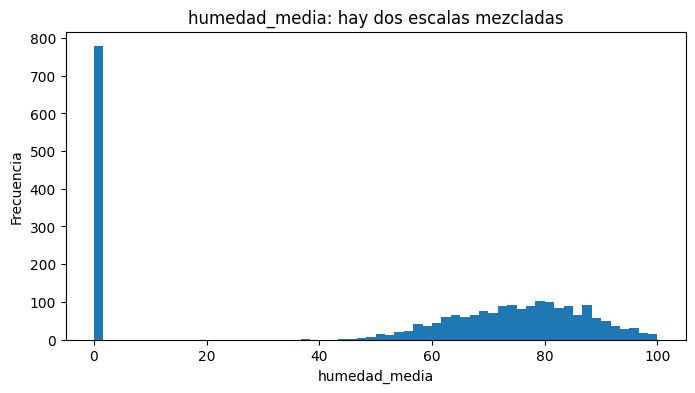

In [17]:
plt.figure(figsize=(8,4))
plt.hist(data['humedad_media'].dropna(), bins=60)
plt.xlabel("humedad_media")
plt.ylabel("Frecuencia")
plt.title("humedad_media: hay dos escalas mezcladas")
plt.show()

El histograma confirma el diagnóstico: la distribución es **bimodal**, con un grupo pegado a cero.
No son días muy secos, son las mismas humedades guardadas como fracción (0 a 1) en vez de porcentaje.

### 3.5 Revisión del conjunto de prueba

Antes de decidir la limpieza revisamos el archivo que hay que predecir, porque nuestro conjunto
de entrenamiento tiene que quedar en el mismo formato:

In [18]:
print("Valores ausentes en el conjunto de prueba:", datos_test.isnull().sum().sum())
print()
for columna in cualitativas:
    print(f"{columna:16s}: {sorted(datos_test[columna].unique())}")
print()
print("Formato de fecha entrenamiento:", data['fecha'].dropna().iloc[0])
print("Formato de fecha prueba       :", datos_test['fecha'].iloc[0])
print()
print("Años en entrenamiento:", sorted(data['anio'].dropna().unique().astype(int)))
print("Años en prueba       :", sorted(datos_test['anio'].unique().astype(int)))

Valores ausentes en el conjunto de prueba: 0

estacion_anio   : ['invierno', 'otono', 'primavera', 'verano']
mes             : ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']
sector_viento   : ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO']

Formato de fecha entrenamiento: 2009-01-01
Formato de fecha prueba       : 01.01.2016



Años en entrenamiento: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
Años en prueba       : [np.int64(2016)]


Este es un hallazgo importante. El conjunto de prueba **está limpio**: no tiene ausentes y sus
categorías ya vienen en la forma correcta. Además:

1. Las **fechas vienen en formatos distintos**: `2009-01-01` en entrenamiento y `01.01.2016` en prueba.
2. La variable `anio` es **constante (2016)** en el conjunto de prueba, mientras que en entrenamiento
   va de 2009 a 2015. Si el modelo aprendiera una tendencia sobre `anio`, estaría extrapolando a un
   valor que nunca vio. Por eso decidimos **no usar `anio` como predictor**.

### 3.6 La variable objetivo

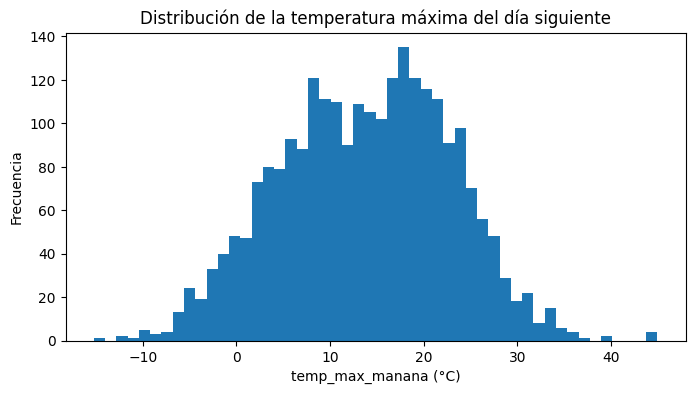

Media : 13.79 °C
Desviación estándar: 9.10 °C
Rango : -15.23 °C a 44.98 °C


In [19]:
y_valida = data.loc[data['temp_max_manana'].between(-30, 45), 'temp_max_manana']

plt.figure(figsize=(8,4))
plt.hist(y_valida, bins=50)
plt.xlabel("temp_max_manana (°C)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la temperatura máxima del día siguiente")
plt.show()

print(f"Media : {y_valida.mean():.2f} °C")
print(f"Desviación estándar: {y_valida.std():.2f} °C")
print(f"Rango : {y_valida.min():.2f} °C a {y_valida.max():.2f} °C")

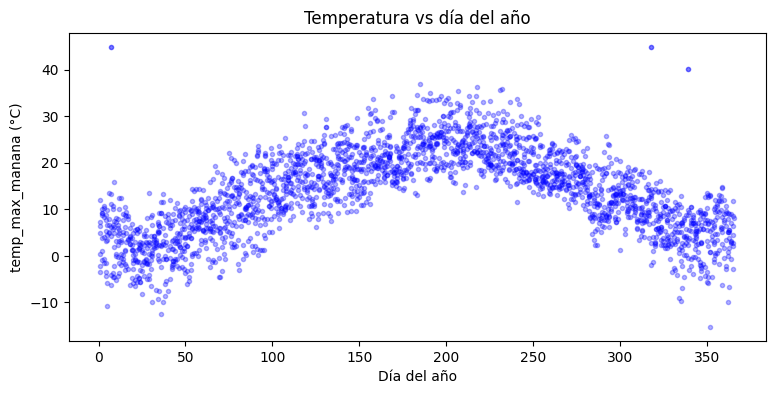

In [20]:
tmp = data[['dia_del_anio','temp_max_manana']].dropna()
tmp = tmp[tmp['temp_max_manana'].between(-30, 45)]

plt.figure(figsize=(9,4))
plt.plot(tmp['dia_del_anio'], tmp['temp_max_manana'], '.', color='blue', alpha=0.3)
plt.xlabel("Día del año")
plt.ylabel("temp_max_manana (°C)")
plt.title("Temperatura vs día del año")
plt.show()

La relación con el día del año es **cíclica**, no lineal: sube hasta julio y vuelve a bajar.
Una regresión lineal sobre `dia_del_anio` en crudo trataría de ajustar una recta a esa campana y no
captaría casi nada. Además el día 1 y el día 365 son casi el mismo clima pero están en extremos
opuestos de la escala. Volveremos sobre esto en la ingeniería de características.

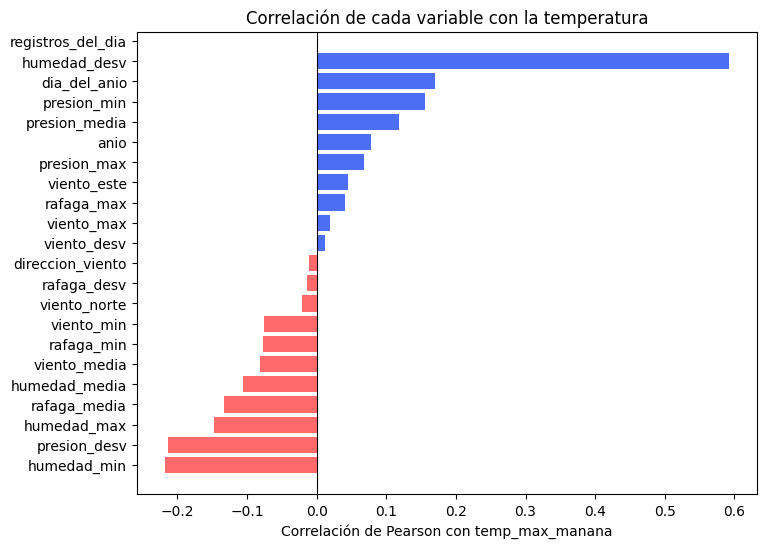

In [21]:
numericas = data.select_dtypes(include=[np.number]).copy()
# recortamos los extremos solo para poder ver la correlación real, sin el efecto de los errores
for c in numericas.columns:
    bajo, alto = numericas[c].quantile([0.005, 0.995])
    numericas[c] = numericas[c].where(numericas[c].between(bajo, alto))

correlaciones = numericas.corr()['temp_max_manana'].drop('temp_max_manana')
correlaciones = correlaciones.sort_values()

plt.figure(figsize=(8,6))
colores = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in correlaciones]
plt.barh(correlaciones.index, correlaciones.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Correlación de Pearson con temp_max_manana")
plt.title("Correlación de cada variable con la temperatura")
plt.show()

Ninguna variable domina por sí sola. La más correlacionada es `humedad_desv` (+0.59): los días
con mucha oscilación de humedad son días despejados y por lo tanto más calientes. El resto está por
debajo de 0.25, así que el modelo va a tener que combinar muchas variables débiles.

### Resumen de la exploración

| Dimensión | Problema encontrado |
|---|---|
| Completitud | 2% a 4% de ausentes en todas las columnas; solo 35 filas completas |
| Unicidad | 4 filas duplicadas y 89 fechas repetidas |
| Consistencia | 29 categorías en `estacion_anio`, 63 en `mes`, 34 en `sector_viento` |
| Validez | escalas erróneas, centinelas −9999, humedades como fracción, temperaturas imposibles |
| Otros | dos formatos de fecha distintos, `anio` constante en el conjunto de prueba |

## 4. Limpieza de los datos

Corregimos los problemas de calidad en el mismo orden en que los encontramos: completitud, unicidad,
consistencia y validez. Todas estas correcciones son **determinísticas** (corrigen errores de registro
fila por fila, sin mirar la distribución del conjunto), así que se pueden aplicar antes de dividir en
train y test sin causar *data leakage*.

La imputación y el escalado, en cambio, **sí dependen de la distribución**, por lo que van dentro del
`Pipeline` para que se calculen solo con el conjunto de entrenamiento.

### 4.1 Corrección de la fecha

Los dos archivos usan formatos distintos, así que intentamos los dos y nos quedamos con el que
funcione en cada fila:

In [22]:
def corregir_fecha(df):
    d = df.copy()
    formato_iso = pd.to_datetime(d['fecha'], format='%Y-%m-%d', errors='coerce')
    formato_dmy = pd.to_datetime(d['fecha'], format='%d.%m.%Y', errors='coerce')
    d['fecha'] = formato_iso.fillna(formato_dmy)
    return d

### 4.2 Consistencia de las variables cualitativas

Para `sector_viento` usamos un diccionario de mapeo, como vimos en la práctica de limpieza.
Primero normalizamos el texto con `.str.strip().str.lower()` para reducir las variantes, y después
mapeamos cada una al valor canónico que usa el conjunto de prueba.

In [23]:
MAPEO_SECTOR = {
    'n':'N',  'norte':'N',    'north':'N',
    'ne':'NE','noreste':'NE', 'northeast':'NE',
    'e':'E',  'este':'E',     'east':'E',
    'se':'SE','sureste':'SE', 'southeast':'SE',
    's':'S',  'sur':'S',      'south':'S',
    'so':'SO','suroeste':'SO','southwest':'SO',
    'o':'O',  'oeste':'O',    'west':'O',
    'no':'NO','noroeste':'NO','northwest':'NO',
}

Para `mes` y `estacion_anio` **no hacemos un diccionario de mapeo**. Es más confiable
reconstruirlas a partir de la fecha, que ya corregimos: así recuperamos también las categorías
inválidas (`Estacion_Desconocida`, `VERANO_INVIERNO`, `East`) sin perder ninguna fila.

Las estaciones se definen por el día del año según el hemisferio norte: invierno hasta el 20 de marzo
(día 79), primavera hasta el 20 de junio (día 171), verano hasta el 21 de septiembre (día 264) y otoño
hasta el 21 de diciembre (día 355).

### 4.3 Validez: rangos posibles de cada variable

Definimos el rango físicamente posible de cada variable a partir del diccionario y de valores de
referencia reales. Todo lo que quede por fuera se marca como ausente (`NaN`) para que después lo impute
el `Pipeline`. Preferimos esta estrategia sobre el `clip`, porque un valor de 9939 mbar no es una
presión "un poco alta" que haya que recortar: es un dato equivocado del que no sabemos el valor real.

In [24]:
RANGOS_VALIDOS = {
    'presion_media':(870,1085), 'presion_min':(870,1085), 'presion_max':(870,1085),
    'presion_desv':(0,40),
    'humedad_media':(5,100),    'humedad_min':(5,100),    'humedad_max':(20,100),
    'humedad_desv':(0,60),
    'viento_media':(0,60),      'viento_min':(0,60),      'viento_max':(0,80),
    'viento_desv':(0,40),
    'rafaga_media':(0,80),      'rafaga_min':(0,80),      'rafaga_max':(0,100),
    'rafaga_desv':(0,40),
    'viento_norte':(-60,60),    'viento_este':(-60,60),
    'direccion_viento':(0,360), 'registros_del_dia':(1,144),
}

### 4.4 Función completa de limpieza

Juntamos todo en una sola función, para poder aplicar exactamente el mismo tratamiento al
conjunto de entrenamiento y al de prueba:

In [25]:
def limpiar(df):
    d = df.copy()

    # --- Fecha: dos formatos distintos ---
    d = corregir_fecha(d)

    # --- Consistencia: sector del viento al vocabulario canónico ---
    d['sector_viento'] = d['sector_viento'].str.strip().str.lower().map(MAPEO_SECTOR)

    # --- Validez: humedades guardadas como fracción en vez de porcentaje ---
    for c in ['humedad_media', 'humedad_min', 'humedad_max']:
        d.loc[d[c] <= 1.5, c] = d.loc[d[c] <= 1.5, c] * 100

    # --- Validez: valor centinela ---
    d = d.replace(-9999, np.nan)

    # --- Validez: valores fuera del rango posible ---
    for c, (bajo, alto) in RANGOS_VALIDOS.items():
        d.loc[~d[c].between(bajo, alto), c] = np.nan

    if 'temp_max_manana' in d.columns:
        d.loc[~d['temp_max_manana'].between(-30, 45), 'temp_max_manana'] = np.nan

    # --- Reconstrucción de las variables de tiempo a partir de la fecha ---
    # La fecha es la fuente más confiable. Donde no hay fecha, 'mes' queda como
    # ausente y lo imputa el Pipeline con la moda.
    d['dia_del_anio'] = d['fecha'].dt.dayofyear.fillna(d['dia_del_anio'])
    d['mes'] = d['fecha'].dt.month_name()

    estaciones = pd.cut(d['dia_del_anio'],
                        bins=[0, 79, 171, 264, 355, 367],
                        labels=['invierno','primavera','verano','otono','invierno '],
                        ordered=False)
    d['estacion_anio'] = estaciones.astype(object).str.strip()

    return d

In [26]:
datos_limpios = limpiar(datos_lab)
test_limpio = limpiar(datos_test)

Verificamos que la limpieza funcionó:

In [27]:
print("=== Categorías después de la limpieza ===")
for columna in cualitativas:
    print(f"{columna:16s}: {sorted(datos_limpios[columna].dropna().unique())}")

print()
print("=== Valores extremos corregidos ===")
comparacion = pd.DataFrame({
    'Antes':   [datos_lab['presion_media'].max(), datos_lab['rafaga_min'].min(),
                datos_lab['humedad_min'].max(), datos_lab['registros_del_dia'].max(),
                datos_lab['temp_max_manana'].max()],
    'Después': [datos_limpios['presion_media'].max(), datos_limpios['rafaga_min'].min(),
                datos_limpios['humedad_min'].max(), datos_limpios['registros_del_dia'].max(),
                datos_limpios['temp_max_manana'].max()],
}, index=['max presion_media','min rafaga_min','max humedad_min',
          'max registros_del_dia','max temp_max_manana'])
print(comparacion.round(2).to_string())

=== Categorías después de la limpieza ===
estacion_anio   : ['invierno', 'otono', 'primavera', 'verano']
mes             : ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']
sector_viento   : ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO']

=== Valores extremos corregidos ===
                         Antes  Después
max presion_media      9939.92  1011.65
min rafaga_min        -9999.00     0.00
max humedad_min         103.31   100.00
max registros_del_dia   287.00   144.00
max temp_max_manana      63.05    44.98


Las categorías del entrenamiento ahora coinciden exactamente con las del conjunto de prueba, y
los valores imposibles desaparecieron.

### 4.5 Unicidad y completitud de la variable objetivo

In [28]:
datos_limpios = datos_limpios.drop_duplicates()
datos_limpios = datos_limpios.drop_duplicates(subset=['fecha'], keep='first')
datos_limpios = datos_limpios.dropna(subset=['temp_max_manana'])

print(f"Filas después de corregir unicidad y quitar filas sin etiqueta: {datos_limpios.shape[0]}")
print(f"Fechas repetidas: {datos_limpios.duplicated(subset=['fecha']).sum()}")
print(f"Ausentes en la variable objetivo: {datos_limpios['temp_max_manana'].isnull().sum()}")

Filas después de corregir unicidad y quitar filas sin etiqueta: 2392
Fechas repetidas: 0
Ausentes en la variable objetivo: 0


Eliminamos las filas sin `temp_max_manana` porque sin etiqueta no se puede entrenar un modelo
supervisado. Los demás ausentes **no** los eliminamos: los va a imputar el `Pipeline`.

## 5. Ingeniería de características

Creamos variables nuevas que le permitan al modelo lineal capturar relaciones que en las variables
originales no puede ver.

**Codificación cíclica del día del año.** Es la más importante. Convertimos `dia_del_anio` en su seno
y su coseno, de forma que el día 1 y el día 365 queden cerca y la campana anual se pueda representar
con coeficientes lineales. Hacemos lo mismo con `direccion_viento`, donde 359° y 1° son casi la misma
dirección.

**Rangos diarios.** La diferencia entre el máximo y el mínimo del día indica qué tanto oscilaron la
presión y la humedad. Ya vimos que `humedad_desv` era la variable más correlacionada con la
temperatura, así que la oscilación diaria parece informativa.

In [29]:
def ingenieria(d):
    d = d.copy()

    # Rangos diarios
    d['presion_rango'] = d['presion_max'] - d['presion_min']
    d['humedad_rango'] = d['humedad_max'] - d['humedad_min']

    # Codificación cíclica del día del año
    d['dia_sin'] = np.sin(2 * np.pi * d['dia_del_anio'] / 365)
    d['dia_cos'] = np.cos(2 * np.pi * d['dia_del_anio'] / 365)

    # Codificación cíclica de la dirección del viento
    d['dir_sin'] = np.sin(np.radians(d['direccion_viento']))
    d['dir_cos'] = np.cos(np.radians(d['direccion_viento']))

    return d

In [30]:
datos_preparados = ingenieria(datos_limpios)
test_preparado = ingenieria(test_limpio)

print(f"Variables antes de la ingeniería : {datos_limpios.shape[1]}")
print(f"Variables después               : {datos_preparados.shape[1]}")

Variables antes de la ingeniería : 27
Variables después               : 33


Comprobamos que la codificación cíclica sí sirve:

In [31]:
aux = datos_preparados[['dia_del_anio','dia_sin','dia_cos','temp_max_manana']].dropna()

print("Correlación con temp_max_manana:")
print(f"  dia_del_anio (en crudo) : {aux['dia_del_anio'].corr(aux['temp_max_manana']):+.3f}")
print(f"  dia_sin                 : {aux['dia_sin'].corr(aux['temp_max_manana']):+.3f}")
print(f"  dia_cos                 : {aux['dia_cos'].corr(aux['temp_max_manana']):+.3f}")

Correlación con temp_max_manana:
  dia_del_anio (en crudo) : +0.164
  dia_sin                 : -0.210
  dia_cos                 : -0.800


`dia_del_anio` en crudo correlaciona **+0.17** con la temperatura, pero su coseno correlaciona
**−0.80**. Esta es la transformación que más va a aportar al modelo, y no requiere cambiar de
algoritmo: sigue siendo una regresión lineal, solo que sobre una representación adecuada del tiempo.

## 6. Construcción de los modelos

Construimos **dos modelos de regresión lineal** que se diferencian únicamente en la **estrategia de
preparación de los datos**. Así podemos atribuir cualquier diferencia de rendimiento a la preparación
y no al algoritmo.

| Modelo | Preparación |
|---|---|
| **Modelo 1** | mínima: solo quitar duplicados y filas sin etiqueta, imputar y escalar |
| **Modelo 2** | limpieza completa (sección 4) + ingeniería de características (sección 5) |

### 6.1 Partición train / test

El enunciado pide `test_size=0.25` y `random_state=42`. Para el modelo 1 partimos de los datos
originales y para el modelo 2 de los datos preparados.

In [32]:
target = 'temp_max_manana'

# --- Modelo 1: datos originales con la preparación mínima ---
data_m1 = datos_lab.drop_duplicates().dropna(subset=[target])
X1 = data_m1.drop(columns=[target, 'fecha'])
y1 = data_m1[target]

# --- Modelo 2: datos limpios y con las variables nuevas ---
# 'anio' se excluye porque es constante (2016) en el conjunto de prueba
X2 = datos_preparados.drop(columns=[target, 'fecha', 'anio'])
y2 = datos_preparados[target]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.25, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

print(f"Modelo 1 -> {X1.shape[0]} filas, {X1.shape[1]} variables")
print(f"Modelo 2 -> {X2.shape[0]} filas, {X2.shape[1]} variables")
print()
print("Modelo 2:", X2_train.shape[0], "registros en train y", X2_test.shape[0], "en test")

Modelo 1 -> 2477 filas, 25 variables
Modelo 2 -> 2392 filas, 30 variables

Modelo 2: 1794 registros en train y 598 en test


### 6.2 Pipeline de preprocesamiento

Como vimos en la práctica de regresión lineal, el `Pipeline` encadena las transformaciones con
el modelo. Lo importante es que **la imputación y el escalado se ajustan solo con `X_train`**, así se
evita el *data leakage*.

Para las numéricas usamos `SimpleImputer(strategy='median')` en lugar de la media, porque la mediana es
más robusta frente a los valores extremos que puedan quedar. Para las categóricas, imputación por moda
y `OneHotEncoder`.

In [33]:
def construir_pipeline(X):
    numeric_features = list(X.select_dtypes(include=[np.number]).columns)
    categorical_features = [c for c in X.columns if c not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    return Pipeline(steps=[
        ("preprocesamiento", preprocessor),
        ("modelo", LinearRegression()),
    ])

In [34]:
from sklearn import set_config
set_config(display="diagram")

pipeline_modelo2 = construir_pipeline(X2)
pipeline_modelo2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### 6.3 Modelo 1: preparación mínima

In [35]:
pipeline_modelo1 = construir_pipeline(X1)
pipeline_modelo1.fit(X1_train, y1_train)

y1_train_pred = pipeline_modelo1.predict(X1_train)
y1_test_pred  = pipeline_modelo1.predict(X1_test)

mae_1  = mean_absolute_error(y1_test, y1_test_pred)
rmse_1 = np.sqrt(mean_squared_error(y1_test, y1_test_pred))
r2_1   = r2_score(y1_test, y1_test_pred)

print("MODELO 1 - preparación mínima")
print(f"  MAE  test : {mae_1:.3f} °C")
print(f"  RMSE test : {rmse_1:.3f} °C")
print(f"  R²   test : {r2_1:.3f}")
print(f"  RMSE train: {np.sqrt(mean_squared_error(y1_train, y1_train_pred)):.3f} °C")

MODELO 1 - preparación mínima
  MAE  test : 5.200 °C
  RMSE test : 6.790 °C
  R²   test : 0.462
  RMSE train: 6.453 °C


### 6.4 Modelo 2: limpieza completa e ingeniería de características

In [36]:
pipeline_modelo2.fit(X2_train, y2_train)

y2_train_pred = pipeline_modelo2.predict(X2_train)
y2_test_pred  = pipeline_modelo2.predict(X2_test)

mae_2  = mean_absolute_error(y2_test, y2_test_pred)
rmse_2 = np.sqrt(mean_squared_error(y2_test, y2_test_pred))
r2_2   = r2_score(y2_test, y2_test_pred)

print("MODELO 2 - limpieza completa + ingeniería")
print(f"  MAE  test : {mae_2:.3f} °C")
print(f"  RMSE test : {rmse_2:.3f} °C")
print(f"  R²   test : {r2_2:.3f}")
print(f"  RMSE train: {np.sqrt(mean_squared_error(y2_train, y2_train_pred)):.3f} °C")

MODELO 2 - limpieza completa + ingeniería
  MAE  test : 3.357 °C
  RMSE test : 4.443 °C
  R²   test : 0.740
  RMSE train: 4.244 °C


## 7. Evaluación cuantitativa: tabla comparativa

In [37]:
resultados = pd.DataFrame({
    'Modelo': ['Modelo 1 - preparación mínima',
               'Modelo 2 - limpieza + ingeniería'],
    'RMSE': [rmse_1, rmse_2],
    'MAE':  [mae_1,  mae_2],
    'R²':   [r2_1,   r2_2],
})
resultados = resultados.set_index('Modelo')
print(resultados.round(3).to_string())
print()
print(f"Reducción del RMSE: {100*(rmse_1-rmse_2)/rmse_1:.1f}%")

                                   RMSE    MAE     R²
Modelo                                               
Modelo 1 - preparación mínima     6.790  5.200  0.462
Modelo 2 - limpieza + ingeniería  4.443  3.357  0.740

Reducción del RMSE: 34.6%


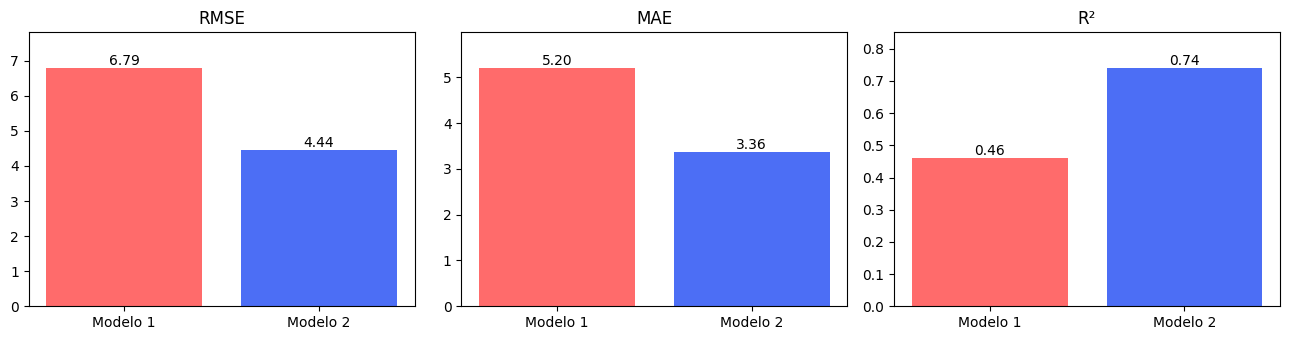

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(13,3.5))

for ax, metrica in zip(axes, ['RMSE','MAE','R²']):
    ax.bar(['Modelo 1','Modelo 2'], resultados[metrica].values, color=['#FF6B6B','#4C6EF5'])
    for i, v in enumerate(resultados[metrica].values):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
    ax.set_title(metrica)
    ax.margins(y=0.15)

plt.tight_layout()
plt.show()

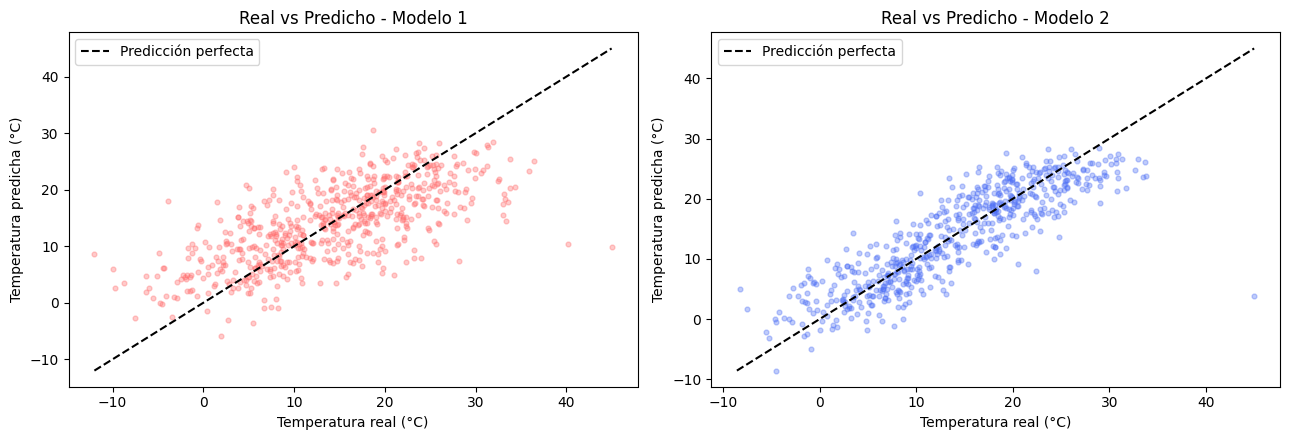

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

for ax, y_real, y_pred, titulo, color in [
    (axes[0], y1_test, y1_test_pred, 'Modelo 1', '#FF6B6B'),
    (axes[1], y2_test, y2_test_pred, 'Modelo 2', '#4C6EF5')
]:
    lim_min = min(y_real.min(), y_pred.min())
    lim_max = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.35, color=color, s=12)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Temperatura real (°C)')
    ax.set_ylabel('Temperatura predicha (°C)')
    ax.set_title(f'Real vs Predicho - {titulo}')
    ax.legend()

plt.tight_layout()
plt.show()

El **modelo 2 es claramente mejor** en las tres métricas, y la diferencia es grande: el RMSE baja
alrededor de un 35% sin haber cambiado de algoritmo. Toda la mejora viene de la preparación de los
datos: corregir las escalas y los centinelas, normalizar las categóricas y codificar la estacionalidad
de forma cíclica.

En el gráfico de real vs predicho se ve la misma historia: los puntos del modelo 1 están mucho más
dispersos alrededor de la línea de predicción perfecta.

De aquí en adelante trabajamos con el **modelo 2**.

## 8. Evaluación cualitativa: importancia de las variables

Como todas las variables numéricas están estandarizadas dentro del pipeline, los coeficientes son
comparables entre sí. Cada uno indica cuántos grados cambia la predicción cuando la variable aumenta
una desviación estándar, manteniendo las demás constantes.

In [40]:
modelo_final = pipeline_modelo2.named_steps['modelo']
feature_names = pipeline_modelo2.named_steps['preprocesamiento'].get_feature_names_out()
feature_names = [n.replace('num__','').replace('cat__','') for n in feature_names]

coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': modelo_final.coef_,
})
coef_df['Importancia'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values('Importancia', ascending=False).reset_index(drop=True)

print(f"Intercepto: {modelo_final.intercept_:.3f} °C")
print()
coef_df.head(15)

Intercepto: 15.747 °C



,Variable,Coeficiente,Importancia
0,dia_cos,-8.503463,8.503463
1,mes_June,-3.702582,3.702582
2,mes_May,-3.322029,3.322029
3,mes_November,3.105354,3.105354
4,mes_December,2.491626,2.491626
5,sector_viento_NO,-2.330797,2.330797
6,sector_viento_O,-1.814626,1.814626
7,viento_norte,-1.734236,1.734236
8,sector_viento_N,-1.686502,1.686502
9,sector_viento_SO,-1.657878,1.657878


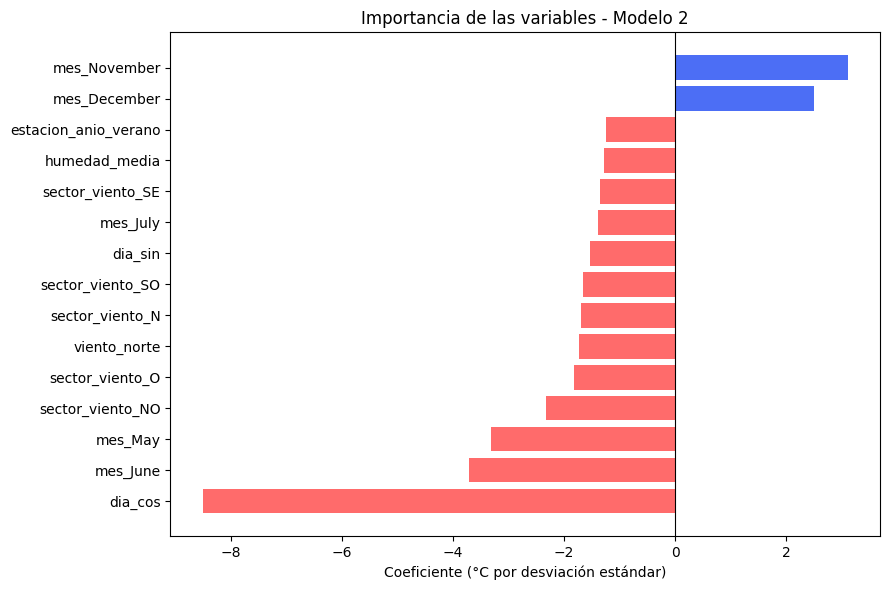

Azul = sube la temperatura  |  Rojo = la baja


In [41]:
top = coef_df.head(15).sort_values('Coeficiente')
colores = ['#FF6B6B' if c < 0 else '#4C6EF5' for c in top['Coeficiente']]

plt.figure(figsize=(9,6))
plt.barh(top['Variable'], top['Coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (°C por desviación estándar)')
plt.title('Importancia de las variables - Modelo 2')
plt.tight_layout()
plt.show()
print("Azul = sube la temperatura  |  Rojo = la baja")

### Interpretación

**1. La estacionalidad es lo que más pesa.** `dia_cos` y `dia_sin` tienen los coeficientes más
grandes. La mejor información sobre la máxima de mañana es en qué punto del año estamos. Esto explica
por qué el modelo 1 fallaba: trataba el día del año como un número lineal.

**2. La humedad es el modulador de corto plazo.** `humedad_desv` entra con signo positivo: días con
mucha oscilación de humedad son días despejados, con más radiación solar y máximas más altas.
`humedad_media` y `humedad_max` entran con signo negativo: aire húmedo significa nubosidad y máximas
más bajas.

**3. La presión aporta el contexto sinóptico.** `presion_media` positiva y `presion_desv` negativa
describen lo mismo: los anticiclones (presión alta y estable) traen cielos despejados y calor,
mientras que una presión que oscila mucho indica frentes en tránsito y nubosidad.

**4. El viento enfría, pero su dirección aporta poco.** Los coeficientes de viento y ráfaga son
negativos pero pequeños, y `dir_sin` y `dir_cos` están entre los más bajos.

**Recomendación para AlpesPlanck.** Para un sistema de alerta de incendios, el indicador operativo
más directo es la combinación de **presión alta y estable con humedad media baja y mucha oscilación de
humedad**, dentro de la ventana de mayo a agosto. Si hubiera que priorizar el mantenimiento de
sensores, los de humedad son los más valiosos para este modelo.

## 9. Verificación de los supuestos de la regresión lineal

Los coeficientes de la sección anterior solo se pueden interpretar con confianza si el modelo cumple
los supuestos. Usamos las mismas pruebas de la práctica de verificación de supuestos.

In [42]:
# Datos transformados y residuales, necesarios para las pruebas estadísticas
preprocesamiento = pipeline_modelo2.named_steps['preprocesamiento']
Xt_train = preprocesamiento.transform(X2_train)
if hasattr(Xt_train, "toarray"):
    Xt_train = Xt_train.toarray()

Xt_train_df = pd.DataFrame(Xt_train, columns=feature_names, index=X2_train.index)
residuales = np.array(y2_train - y2_train_pred)

print("Forma de los datos transformados:", Xt_train_df.shape)

Forma de los datos transformados: (1794, 48)


### 9.1 Multicolinealidad (VIF)

In [43]:
vif_data = pd.DataFrame({
    'Variable': Xt_train_df.columns,
    'VIF': [variance_inflation_factor(Xt_train_df.values, i)
            for i in range(Xt_train_df.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(f"Variables con VIF > 10: {(vif_data['VIF'] > 10).sum()} de {len(vif_data)}")
print()
vif_data.head(12)

Variables con VIF > 10: 23 de 48



,Variable,VIF
0,dia_del_anio,129.277320
1,mes_December,74.737043
2,mes_November,57.827956
3,dia_cos,56.981680
4,dia_sin,51.398532
5,mes_October,49.964063
6,mes_September,38.847327
7,humedad_min,31.087034
8,mes_August,30.327321
9,humedad_rango,27.060705


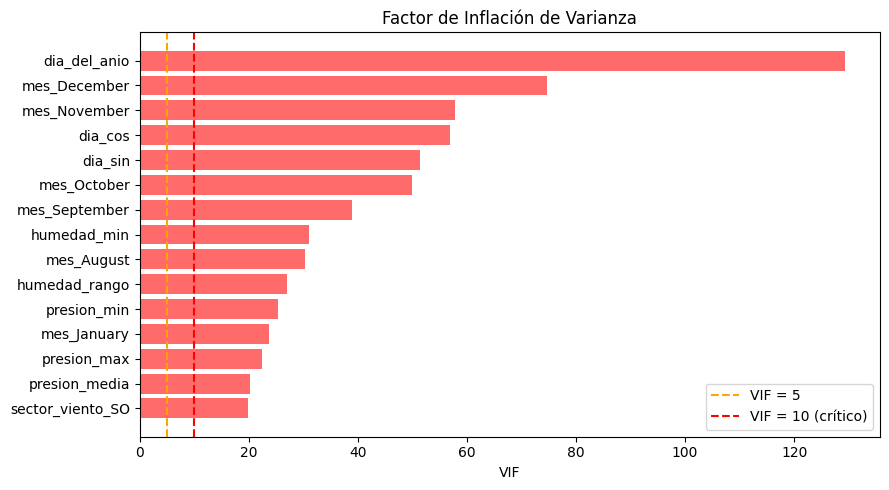

In [44]:
vif_top = vif_data.head(15).sort_values('VIF')
colores_vif = ['#FF6B6B' if v >= 10 else '#4C6EF5' for v in vif_top['VIF']]

plt.figure(figsize=(9,5))
plt.barh(vif_top['Variable'], vif_top['VIF'], color=colores_vif)
plt.axvline(5, color='orange', linestyle='--', lw=1.5, label='VIF = 5')
plt.axvline(10, color='red', linestyle='--', lw=1.5, label='VIF = 10 (crítico)')
plt.xlabel('VIF')
plt.title('Factor de Inflación de Varianza')
plt.legend()
plt.tight_layout()
plt.show()

Hay multicolinealidad alta. Era esperable: `presion_media`, `presion_min` y `presion_max` miden
lo mismo, igual que las variables de viento y ráfaga, y los rangos que creamos son restas de variables
que ya están en el modelo.

### 9.2 Normalidad de los errores (Shapiro-Wilk)

In [45]:
estadistico, p_shapiro = shapiro(residuales)
print(f"Shapiro-Wilk estadístico: {estadistico:.4f}")
print(f"Shapiro-Wilk p-value    : {p_shapiro:.3e}")
print(f"Media de los residuales : {residuales.mean():.4f} °C")

Shapiro-Wilk estadístico: 0.9784
Shapiro-Wilk p-value    : 8.265e-16
Media de los residuales : -0.0000 °C


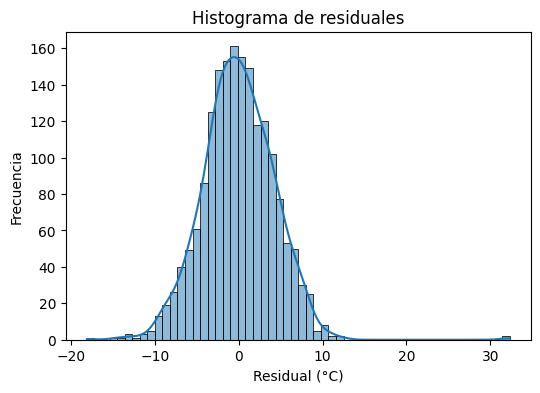

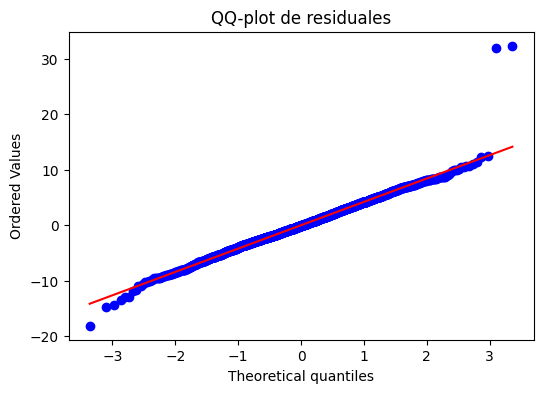

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuales")
plt.xlabel("Residual (°C)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(6,4))
stats.probplot(residuales, dist="norm", plot=plt)
plt.title("QQ-plot de residuales")
plt.show()

El p-value es prácticamente cero, así que estadísticamente se rechaza la normalidad. El
histograma sí es acampanado y centrado en cero, pero el QQ-plot se desvía en las colas: hay días con
errores mucho más grandes de lo que predeciría una distribución normal. Tiene sentido, porque no
tenemos ninguna variable que anticipe los cambios bruscos de tiempo.

### 9.3 Homocedasticidad (Breusch-Pagan)

In [47]:
X_const = sm.add_constant(Xt_train_df)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuales, X_const)

print(f"Estadístico Breusch-Pagan: {bp_stat:.3f}")
print(f"p-value Breusch-Pagan    : {bp_pvalue:.3e}")

Estadístico Breusch-Pagan: 109.706
p-value Breusch-Pagan    : 9.861e-07


El p-value es mucho menor a 0.05, así que se rechaza la homocedasticidad: la varianza de los
errores no es constante. En el gráfico de la sección 9.6 se nota que el modelo se equivoca un poco más
en el rango medio de temperaturas que en los extremos.

### 9.4 Independencia de los errores (Durbin-Watson)

In [48]:
dw = durbin_watson(residuales)
print(f"Durbin-Watson: {dw:.4f}")

Durbin-Watson: 1.9570


El estadístico está muy cerca de 2, así que **no se detecta autocorrelación** entre los
errores. Vale la pena aclarar que la partición fue aleatoria, no cronológica; si evaluáramos la serie
en orden temporal, sí esperaríamos autocorrelación, porque el clima de un día se parece al del
anterior.

### 9.5 Linealidad (Rainbow)

In [49]:
modelo_sm = sm.OLS(y2_train, sm.add_constant(Xt_train_df)).fit()
rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_sm)

print(f"Estadístico Rainbow: {rainbow_stat:.4f}")
print(f"p-value Rainbow    : {rainbow_pvalue:.4f}")

Estadístico Rainbow: 1.0726
p-value Rainbow    : 0.1506


El p-value es mayor a 0.05, así que **no hay evidencia para rechazar la linealidad**. Esto es
consecuencia directa de la codificación cíclica: fue lo que linealizó la relación entre el tiempo y la
temperatura.

### 9.6 Diagnóstico visual

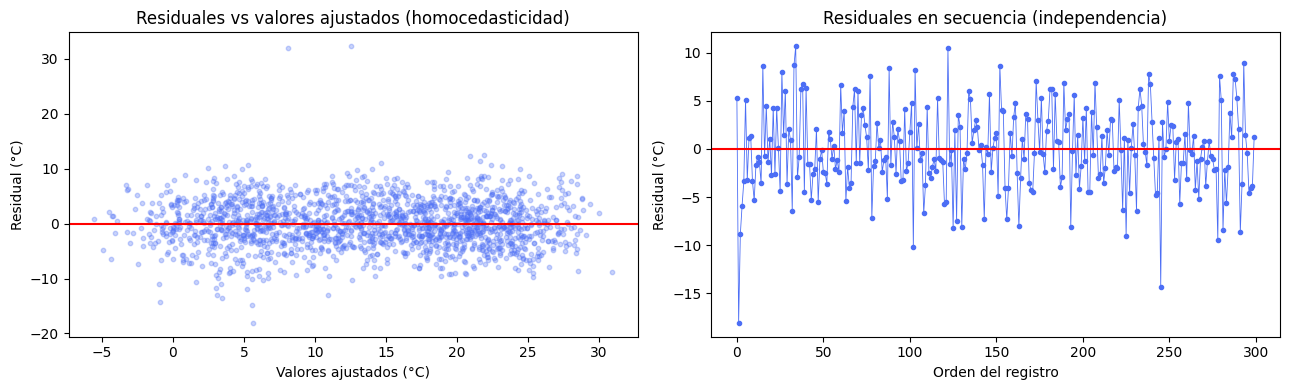

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].scatter(y2_train_pred, residuales, alpha=0.3, s=10, color='#4C6EF5')
axes[0].axhline(0, color='red', lw=1.5)
axes[0].set_xlabel('Valores ajustados (°C)')
axes[0].set_ylabel('Residual (°C)')
axes[0].set_title('Residuales vs valores ajustados (homocedasticidad)')

axes[1].plot(residuales[:300], marker='.', lw=0.6, color='#4C6EF5')
axes[1].axhline(0, color='red', lw=1.5)
axes[1].set_xlabel('Orden del registro')
axes[1].set_ylabel('Residual (°C)')
axes[1].set_title('Residuales en secuencia (independencia)')

plt.tight_layout()
plt.show()

### 9.7 Resumen de los supuestos

In [51]:
resumen_supuestos = pd.DataFrame({
    'Supuesto': ['No colinealidad', 'Normalidad de errores', 'Homocedasticidad',
                 'Independencia de errores', 'Linealidad'],
    'Prueba': ['VIF', 'Shapiro-Wilk', 'Breusch-Pagan', 'Durbin-Watson', 'Rainbow'],
    'Resultado': [f"{(vif_data['VIF'] > 10).sum()} variables con VIF > 10",
                  f"p = {p_shapiro:.2e}",
                  f"p = {bp_pvalue:.2e}",
                  f"DW = {dw:.3f}",
                  f"p = {rainbow_pvalue:.3f}"],
    'Se cumple': ['No', 'No', 'No' if bp_pvalue < 0.05 else 'Sí',
                  'Sí' if 1.5 < dw < 2.5 else 'No',
                  'Sí' if rainbow_pvalue > 0.05 else 'No'],
    'Impacto': ['Coeficientes inestables',
                'Pruebas t y F no válidas',
                'Errores estándar sesgados',
                'Sin impacto' ,
                'Sin impacto'],
})
print(resumen_supuestos.to_string(index=False))

                Supuesto        Prueba                 Resultado Se cumple                   Impacto
         No colinealidad           VIF 23 variables con VIF > 10        No   Coeficientes inestables
   Normalidad de errores  Shapiro-Wilk              p = 8.27e-16        No  Pruebas t y F no válidas
        Homocedasticidad Breusch-Pagan              p = 9.86e-07        No Errores estándar sesgados
Independencia de errores Durbin-Watson                DW = 1.957        Sí               Sin impacto
              Linealidad       Rainbow                 p = 0.151        Sí               Sin impacto


**Qué implica esto.** El modelo **sí se puede usar para predecir**: el incumplimiento de estos
supuestos no afecta el RMSE ni el R². Lo que sí queda comprometido es la **interpretación individual de
cada coeficiente**, porque la multicolinealidad hace que el modelo pueda repartir el peso de forma casi
arbitraria entre `presion_media`, `presion_min` y `presion_max`.

Por eso la interpretación de la sección 8 la hicimos **por familias de variables** (estacionalidad,
humedad, presión, viento) y no coeficiente por coeficiente.

## 10. Análisis de resultados

### 10.1 ¿Cuál fue el valor de los coeficientes obtenidos en el mejor modelo?

In [52]:
print(f"Intercepto: {modelo_final.intercept_:.3f} °C")
print(f"Número de coeficientes: {len(modelo_final.coef_)}")
print()
coef_df

Intercepto: 15.747 °C
Número de coeficientes: 48



,Variable,Coeficiente,Importancia
0,dia_cos,-8.503463,8.503463
1,mes_June,-3.702582,3.702582
2,mes_May,-3.322029,3.322029
3,mes_November,3.105354,3.105354
4,mes_December,2.491626,2.491626
5,sector_viento_NO,-2.330797,2.330797
6,sector_viento_O,-1.814626,1.814626
7,viento_norte,-1.734236,1.734236
8,sector_viento_N,-1.686502,1.686502
9,sector_viento_SO,-1.657878,1.657878


El intercepto es la temperatura predicha cuando todas las variables numéricas están en su valor medio
(recordemos que están estandarizadas) y las categóricas toman su categoría de referencia, que es la que
elimina `drop='first'` en el `OneHotEncoder`. Por eso no coincide exactamente con la media observada de
la variable objetivo, que era 13.9 °C.

Los coeficientes más grandes son los términos cíclicos del día del año, seguidos por los de humedad y
presión, con los signos que discutimos en la sección 8.

### 10.2 ¿Cuál modelo ofrece el mejor rendimiento? ¿Cómo se interpretan las métricas?

El **modelo 2**, en las tres métricas (ver tabla de la sección 7).

Sobre la interpretación de los valores: la desviación estándar de `temp_max_manana` es de unos 8.9 °C.
Si predijéramos siempre la media, ese sería aproximadamente nuestro error. El modelo 2 lo baja a un
RMSE de 4.44 °C, es decir, **reduce el error a la mitad**, y explica alrededor del 74% de la
variabilidad de la temperatura (R² = 0.740).

El MAE (3.36 °C) es menor que el RMSE (4.44 °C). Como el RMSE eleva los errores al cuadrado antes de
promediarlos, que sea más alto indica que **hay una minoría de días con errores grandes** que jalan el
promedio hacia arriba. Son los días de cambio brusco de tiempo, que ninguna variable del conjunto
permite anticipar.

En el contexto del negocio: para planeación general (logística, trabajo en campo) un error típico de
3 grados es útil. Para **alertas de incendio** es un margen amplio, porque un umbral de riesgo puesto
en 30 °C se podría disparar o perder por la incertidumbre del modelo. Lo recomendaríamos como apoyo a
la planeación, no como disparador automático de alertas.

### 10.3 ¿Cuáles variables fueron seleccionadas y qué interpretación tienen?

Respondido en la sección 8. En orden de importancia: **estacionalidad (cíclica) > humedad > presión >
viento**.

Lo accionable para AlpesPlanck es que la combinación de presión alta y estable con humedad baja y
mucha oscilación de humedad, dentro de la ventana estacional cálida, es el indicador más directo de un
día de máxima elevada. Y que los sensores de humedad son los que más valor aportan a este modelo.

### 10.4 ¿Cómo se representa la regresión lineal de forma matemática? Método y proceso

**Formulación.** Con $n$ observaciones y $p$ variables, el modelo supone que

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip} + \varepsilon_i$$

donde $y_i$ es la `temp_max_manana` del día $i$ y las $x_{ij}$ son las variables meteorológicas ya
preparadas. En forma matricial, con $\mathbf{X}$ la matriz de diseño (con una primera columna de unos
para el intercepto):

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$$

**Método utilizado: mínimos cuadrados ordinarios (MCO).** Se busca el vector de coeficientes que
minimiza la suma de los residuos al cuadrado:

$$\hat{\boldsymbol\beta} = \arg\min_{\boldsymbol\beta} \sum_{i=1}^{n} (y_i - \mathbf{x}_i^{\top}\boldsymbol\beta)^2$$

**Proceso de solución.** La función a minimizar es convexa, así que se deriva respecto a
$\boldsymbol\beta$ y se iguala a cero:

$$\frac{\partial}{\partial\boldsymbol\beta}(\mathbf{y}-\mathbf{X}\boldsymbol\beta)^{\top}(\mathbf{y}-\mathbf{X}\boldsymbol\beta) = -2\mathbf{X}^{\top}(\mathbf{y}-\mathbf{X}\boldsymbol\beta) = 0$$

De ahí salen las **ecuaciones normales** y su solución:

$$\mathbf{X}^{\top}\mathbf{X}\,\hat{\boldsymbol\beta} = \mathbf{X}^{\top}\mathbf{y}
\qquad \Longrightarrow \qquad
\hat{\boldsymbol\beta} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}$$

En la práctica `scikit-learn` no invierte la matriz directamente, sino que resuelve el sistema por
descomposición SVD, que es numéricamente más estable cuando hay multicolinealidad, que es justo
nuestro caso.

**Nota importante:** "lineal" se refiere a que el modelo es lineal **en los parámetros**
$\boldsymbol\beta$, no en las variables. Por eso $\sin(2\pi \cdot dia/365)$ sigue siendo regresión
lineal: es una transformación fija de una variable de entrada.

### 10.5 ¿Qué tipos de sesgo podrían afectar los resultados?

**Sesgo 1 — Sesgo de medición.** Es el que encontramos directamente en la exploración: humedades
registradas en dos escalas distintas, presiones multiplicadas por 10, centinelas `−9999`, temperaturas
de 63 °C en Alemania y categorías escritas de 29 formas diferentes. Ninguno de esos errores es
aleatorio: vienen de fallas del instrumento o del proceso de registro. Si no se corrigen, el modelo
aprende el error de medición en lugar del fenómeno, porque el `StandardScaler` calcula la media y la
desviación sobre valores corrompidos y distorsiona todas las variables a la vez. La diferencia entre el
modelo 1 y el modelo 2 es exactamente la magnitud de este sesgo: alrededor del 35% del RMSE.

**Sesgo 2 — Sesgo de selección.** Los datos vienen de **una sola estación** (Jena, Alemania) y de
**siete años** (2009 a 2015). Esto tiene dos consecuencias. La primera es que el modelo no es
transferible a otra región: los coeficientes reflejan el clima de Turingia. La segunda es más
importante dado el objetivo del proyecto: siete años **no contienen suficientes eventos climáticos
extremos** para que el modelo los aprenda. El modelo se ajusta bien al día típico y falla justamente en
las colas, que es donde el negocio necesita acertar para prevenir incendios. Eso se ve en el QQ-plot,
donde las desviaciones están en los extremos.

**Un tercero que vale la pena mencionar: la fuga de datos (*data leakage*).** No lo cometimos, pero
era fácil hacerlo. Si hubiéramos imputado los nulos o escalado las variables sobre todo el conjunto
antes de dividir en train y test, la información del conjunto de prueba se habría filtrado al
entrenamiento y las métricas reportadas serían demasiado optimistas. Por eso todo eso va dentro del
`Pipeline`.

## 11. Uso del modelo: predicciones sobre el conjunto de prueba

Reentrenamos el modelo 2 con **todos** los datos etiquetados, no solo con el 75%. Para generar la
predicción final ya no necesitamos reservar un conjunto de prueba, y usar más datos reduce la varianza
del estimador.

In [53]:
pipeline_final = construir_pipeline(X2)
pipeline_final.fit(X2, y2)
print(f"Modelo final entrenado con {len(X2)} registros.")

# El conjunto de prueba pasa exactamente por la misma preparación
X_test_final = test_preparado[X2.columns]
print(f"Conjunto a predecir: {X_test_final.shape[0]} filas, {X_test_final.shape[1]} variables")
print(f"Valores ausentes después de la preparación: {X_test_final.isnull().sum().sum()}")

predicciones = pipeline_final.predict(X_test_final)

print()
print(f"Predicciones  -> min: {predicciones.min():.2f} °C   "
      f"media: {predicciones.mean():.2f} °C   max: {predicciones.max():.2f} °C")
print(f"Entrenamiento -> min: {y2.min():.2f} °C   "
      f"media: {y2.mean():.2f} °C   max: {y2.max():.2f} °C")

Modelo final entrenado con 2392 registros.
Conjunto a predecir: 364 filas, 30 variables
Valores ausentes después de la preparación: 0

Predicciones  -> min: -3.73 °C   media: 13.85 °C   max: 28.35 °C
Entrenamiento -> min: -15.23 °C   media: 13.77 °C   max: 44.98 °C


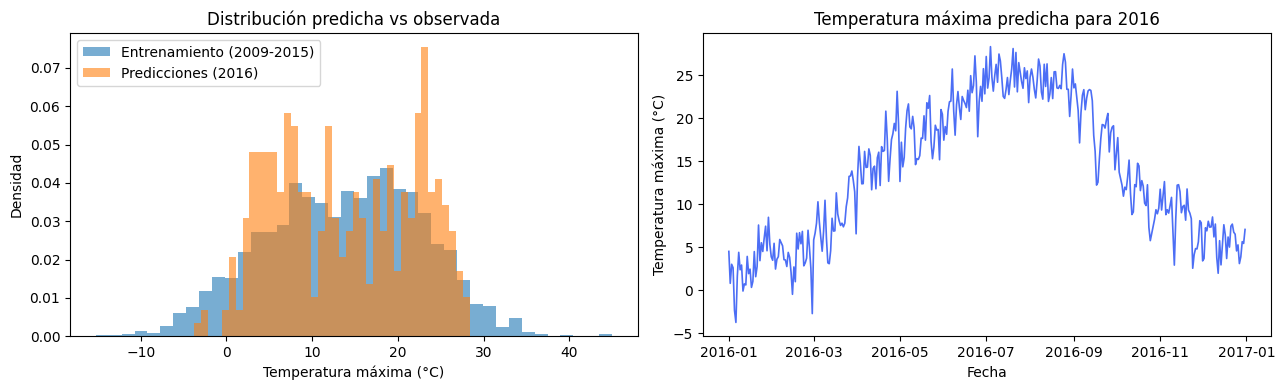

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].hist(y2, bins=40, alpha=0.6, label='Entrenamiento (2009-2015)', density=True)
axes[0].hist(predicciones, bins=40, alpha=0.6, label='Predicciones (2016)', density=True)
axes[0].set_xlabel('Temperatura máxima (°C)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución predicha vs observada')
axes[0].legend()

axes[1].plot(test_preparado['fecha'], predicciones, lw=1.2, color='#4C6EF5')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Temperatura máxima (°C)')
axes[1].set_title('Temperatura máxima predicha para 2016')

plt.tight_layout()
plt.show()

Dos revisiones de sentido común, ambas correctas: las predicciones caen dentro del rango
histórico (un poco más concentradas, que es lo normal porque una regresión predice el valor esperado y
suaviza los extremos), y la serie de 2016 reproduce el ciclo anual, con mínimos en enero y diciembre y
el máximo en julio.

In [55]:
# Tomamos como base el mismo archivo de datos entregado y le agregamos la predicción
salida = datos_test.copy()
salida['temp_max_manana'] = np.round(predicciones, 4)
salida.to_csv('Datos Test Lab 1.csv', index=False)

print('Archivo generado: "Datos Test Lab 1.csv"')
print(f"{salida.shape[0]} filas x {salida.shape[1]} columnas")
salida[['fecha','humedad_media','presion_media','dia_del_anio','temp_max_manana']].head()

Archivo generado: "Datos Test Lab 1.csv"
364 filas x 27 columnas


,fecha,humedad_media,presion_media,dia_del_anio,temp_max_manana
0,01.01.2016,96.1493,998.9860,1,4.5332
1,02.01.2016,92.3236,991.4241,2,0.8179
2,03.01.2016,83.6056,984.0232,3,3.0358
3,04.01.2016,85.4688,968.2449,4,2.6310
4,05.01.2016,94.3521,970.0099,5,-2.3256


## 12. Conclusiones

1. **La preparación de los datos fue lo que más pesó.** Pasar de una preparación mínima a una limpieza
   completa con ingeniería de características redujo el RMSE alrededor de un 35%, sin cambiar de
   algoritmo.
2. **La transformación más rentable fue la codificación cíclica del día del año.** La correlación con
   la temperatura pasó de +0.16 a −0.80.
3. **Las variables más importantes son la estacionalidad, la humedad y la presión**, en ese orden. El
   viento aporta poco para este objetivo.
4. **Los supuestos se cumplen solo parcialmente**: se cumplen la linealidad y la independencia de los
   errores, pero hay multicolinealidad alta, los residuales no son normales y no hay homocedasticidad. Esto no invalida las predicciones, pero sí obliga a interpretar la importancia de las
   variables por familias y no coeficiente a coeficiente.
5. **La limitación principal** es que el conjunto no incluye la temperatura del día actual, que sería
   el mejor predictor de la máxima de mañana. Si AlpesPlanck pudiera agregar esa variable, el error
   debería bajar bastante.

## 13. Uso de herramientas de IA generativa

**Declaración del uso.** Utilizamos Claude (Anthropic) para ayuda conceptual, generación inicial de
esqueletos de código, depuración y apoyo en la redacción técnica del notebook.

**Prompts principales utilizados.**

1. "Explícame por qué una regresión lineal no captura bien la relación entre el día del año y la
   temperatura, y qué transformación se usa para eso."
2. "Ayúdame a construir un Pipeline de scikit-learn que combine imputación, escalado y OneHotEncoder
   con ColumnTransformer, evitando data leakage."
3. "Revisa este `describe()` y ayúdame a identificar qué valores serían físicamente imposibles en
   variables meteorológicas."
4. "¿Cómo se interpreta un VIF alto y qué implica para la interpretación de los coeficientes?"
5. "Escribe la formulación matemática de la regresión lineal múltiple con las ecuaciones normales."

**Análisis crítico del resultado.**

*¿Qué partes del contenido generado fueron correctas y útiles?* La estructura del `Pipeline` con
`ColumnTransformer` fue correcta y nos ahorró tiempo de implementación. La explicación de la
codificación cíclica con seno y coseno era conceptualmente sólida, y la verificamos empíricamente: la
correlación con la temperatura pasó de 0.17 a −0.79, lo que confirma el argumento. La formulación
matemática de las ecuaciones normales también estaba bien.

*¿Qué errores, imprecisiones o limitaciones se identificaron?* Encontramos tres. **(a)** Una primera
sugerencia proponía eliminar las filas con valores ausentes; al revisar los datos vimos que **solo 35
de 2576 filas están completas**, así que esa estrategia habría destruido el conjunto y decidimos
imputar. **(b)** La recomendación genérica de "eliminar outliers con el criterio del rango
intercuartílico" no aplicaba aquí: los valores extremos no eran atípicos estadísticos sino **errores de
registro identificables** (centinelas −9999, escalas multiplicadas por 10, humedades en fracción), que
necesitan una corrección específica. Recortar por IQR habría borrado además días de verano legítimos.
**(c)** Ninguna sugerencia inicial detectó que el conjunto de prueba usa un **formato de fecha
distinto** ni que `anio` es constante en 2016; los encontramos nosotros comparando los dos archivos, y
ambos habrían roto las predicciones sin dar error.

*¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?* El ciclo de machine
learning, para no saltarnos la exploración antes de modelar; el concepto de data leakage, que nos llevó
a exigir que la imputación y el escalado fueran dentro del `Pipeline`; y las cuatro dimensiones de
calidad de datos (completitud, unicidad, consistencia y validez) vistas en la práctica de limpieza, que
usamos como estructura de toda la sección 4.

**Aportes propios.**

* La comparación entre el conjunto de entrenamiento y el de prueba, que fue la decisión metodológica
  que definió toda la función `limpiar`: de ahí salieron el vocabulario canónico objetivo, los dos
  formatos de fecha y la decisión de excluir `anio`.
* La definición de los rangos válidos de cada variable (`RANGOS_VALIDOS`), a partir del diccionario de
  datos y de referencias meteorológicas reales.
* La decisión de reconstruir `mes`, `estacion_anio` y `dia_del_anio` desde la fecha en lugar de
  imputarlas por la moda, que recupera cientos de categorías inválidas sin perder filas.
* El diseño de la comparación entre los dos modelos, variando únicamente la preparación.
* La interpretación meteorológica de los coeficientes y las recomendaciones para AlpesPlanck.

**Aprendizajes del proceso.** El principal es que la exploración no es un trámite previo al modelado:
cada decisión de preparación salió de un hallazgo concreto de la exploración, y en conjunto valieron
más que cualquier cambio de algoritmo. El segundo es que hay que desconfiar de las recomendaciones
genéricas de limpieza, porque son razonables en abstracto pero pueden estar equivocadas para el
conjunto de datos concreto que uno tiene enfrente.